### Transfer Learning using Resnet50 in Pytorch

### Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets
import matplotlib.pyplot as plt
import numpy as np
import os

### Check GPU availability

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Image Transformations

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Load the dataset

In [6]:
# Load custom dataset

data_dir = "D:/Programming/Programe MatLab/ImageProcessing/chest-xray-classifier/data/augmented"
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

### Getting the Dataset Info

In [7]:
def get_dataset_info(dataset):
    print(f"Number of classes: {len(dataset.classes)}")
    print(f"Class names: {dataset.classes}")
    print(f"Number of images: {len(dataset)}")
    class_counts = {cls: 0 for cls in dataset.classes}
    for _, label in dataset.samples:
        class_counts[dataset.classes[label]] += 1   
    print("Class distribution:")
    for cls, count in class_counts.items():
        print(f"{cls}: {count}")

print("Training Dataset Info:")
get_dataset_info(train_dataset)
print("Validation Dataset Info:")
get_dataset_info(val_dataset)

Training Dataset Info:
Number of classes: 4
Class names: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
Number of images: 17742
Class distribution:
COVID19: 1071
NORMAL: 3738
PNEUMONIA: 11298
TURBERCULOSIS: 1635
Validation Dataset Info:
Number of classes: 4
Class names: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
Number of images: 2313
Class distribution:
COVID19: 318
NORMAL: 702
PNEUMONIA: 1170
TURBERCULOSIS: 123


### Pretrained Model Loading

In [8]:
model = models.resnet50(pretrained=True)

d:\Anaconda\envs\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Anaconda\envs\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

### Loss Function & Optimizer

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

### Model Training

In [11]:
import time

def train(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    start_time = time.time()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct/total}")
        end_time = time.time()
        print(f"Total Training Time: {end_time - start_time:.2f} seconds")

### Model Evaluation

In [12]:
def evaluate(model, val_loader, criterion):
    model.eval()
    total = 0
    correct = 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    print(f"Validation Loss: {val_loss/len(val_loader):.4f}, Accuracy: {100 * correct/total:.2f}%")

### Model Inferencing

In [13]:
def infer(model, image_path, transform):
    model.eval()
    image = Image.open(image_path)
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    class_name = train_dataset.classes[predicted.item()]
    print(f"Predicted class: {class_name}")
    return class_name

### Visulaizing our predictions

In [14]:
def visualize_predictions(model, val_loader, transform):
    model.eval()
    images, labels = next(iter(val_loader))
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    fig = plt.figure(figsize=(10,10))
    for i in range(9):
        ax = fig.add_subplot(3, 3, i+1, xticks=[], yticks=[])
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        ax.imshow(img)
        ax.set_title(f"Pred: {train_dataset.classes[preds[i].item()]}")
    plt.show()

Epoch [1/5], Loss: 0.4249, Accuracy: 84.51132904971254
Total Training Time: 1361.92 seconds
Epoch [2/5], Loss: 0.2856, Accuracy: 89.24585728779168
Total Training Time: 2023.96 seconds
Epoch [3/5], Loss: 0.2566, Accuracy: 90.55348889640402
Total Training Time: 2664.39 seconds
Epoch [4/5], Loss: 0.2391, Accuracy: 90.87476045541652
Total Training Time: 3275.04 seconds
Epoch [5/5], Loss: 0.2296, Accuracy: 91.19039567128847
Total Training Time: 3876.50 seconds
Validation Loss: 0.8375, Accuracy: 74.23%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9098039863109589].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].
Clip

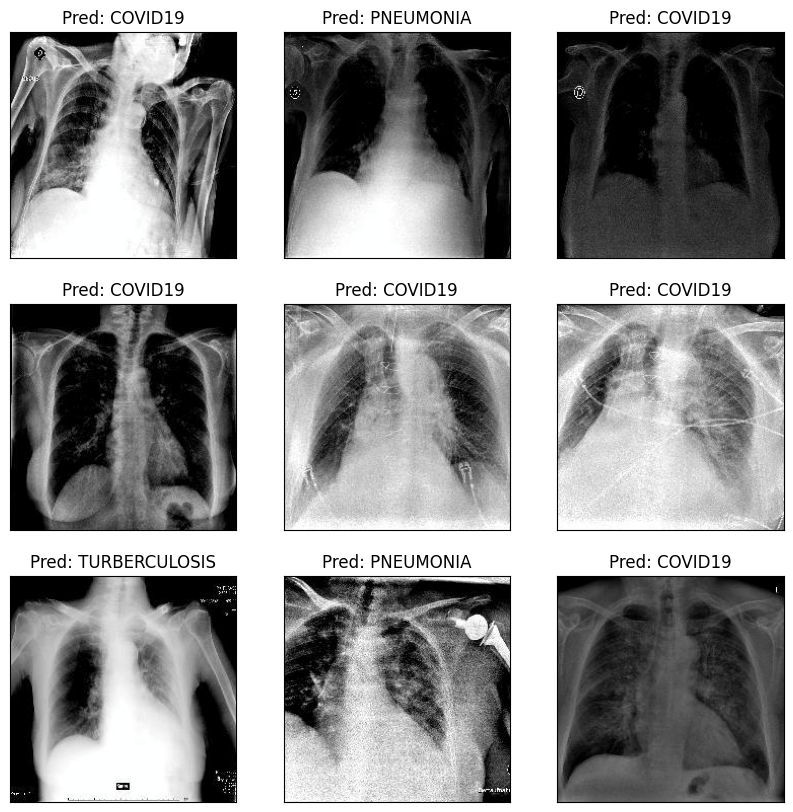

In [15]:
train(model, train_loader, criterion, optimizer, epochs=5)
evaluate(model, val_loader, criterion)

visualize_predictions(model, val_loader, transform)

### Save the model

In [18]:
torch.save(model.state_dict(), "D:/Programming/Programe MatLab/ImageProcessing/chest-xray-classifier/models/model1.pth")